In [12]:
import pandas as pd
import numpy as np
from plotnine import *
import scanpy as sc

In [2]:
cell_info = pd.read_csv("../../../wherry_dataset/fragment_files/GSM5975167_scA_101_singlecell.csv.gz")
cell_info.head()

,barcode,total,duplicate,chimeric,unmapped,lowmapq,mitochondrial,passed_filters,cell_id,is__cell_barcode,TSS_fragments,DNase_sensitive_region_fragments,enhancer_region_fragments,promoter_region_fragments,on_target_fragments,blacklist_region_fragments,peak_region_fragments
0,NO_BARCODE,20385111,11489170,195011,2203532,1082986,75295,5339117,NaN,0,0,0,0,0,0,0,0
1,AAACGAAAGAAACGCC-1,7,1,1,4,0,0,1,NaN,0,1,1,0,1,1,0,1
2,AAACGAAAGAAAGCAG-1,14,3,0,6,0,0,5,NaN,0,3,4,2,2,5,0,4
3,AAACGAAAGAAAGGGT-1,2,1,0,0,0,0,1,NaN,0,0,0,0,0,0,0,0
4,AAACGAAAGAAATACC-1,11,2,0,8,0,0,1,NaN,0,0,0,0,0,0,0,0


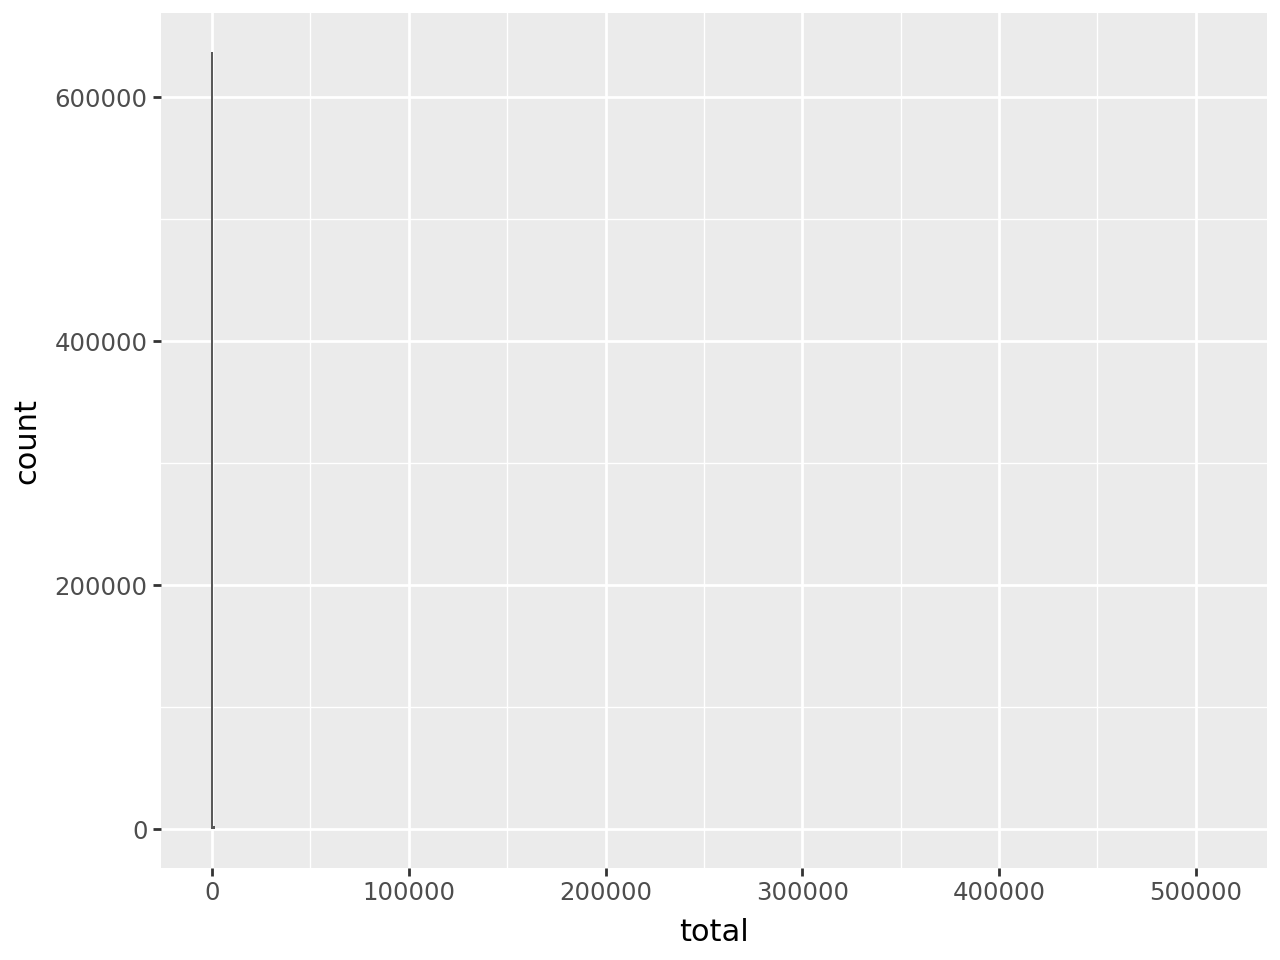

In [3]:
ggplot(cell_info[cell_info["barcode"] != "NO_BARCODE"], aes(x="total", color = "is__cell_barcode")) + geom_histogram(
    bins = 500)

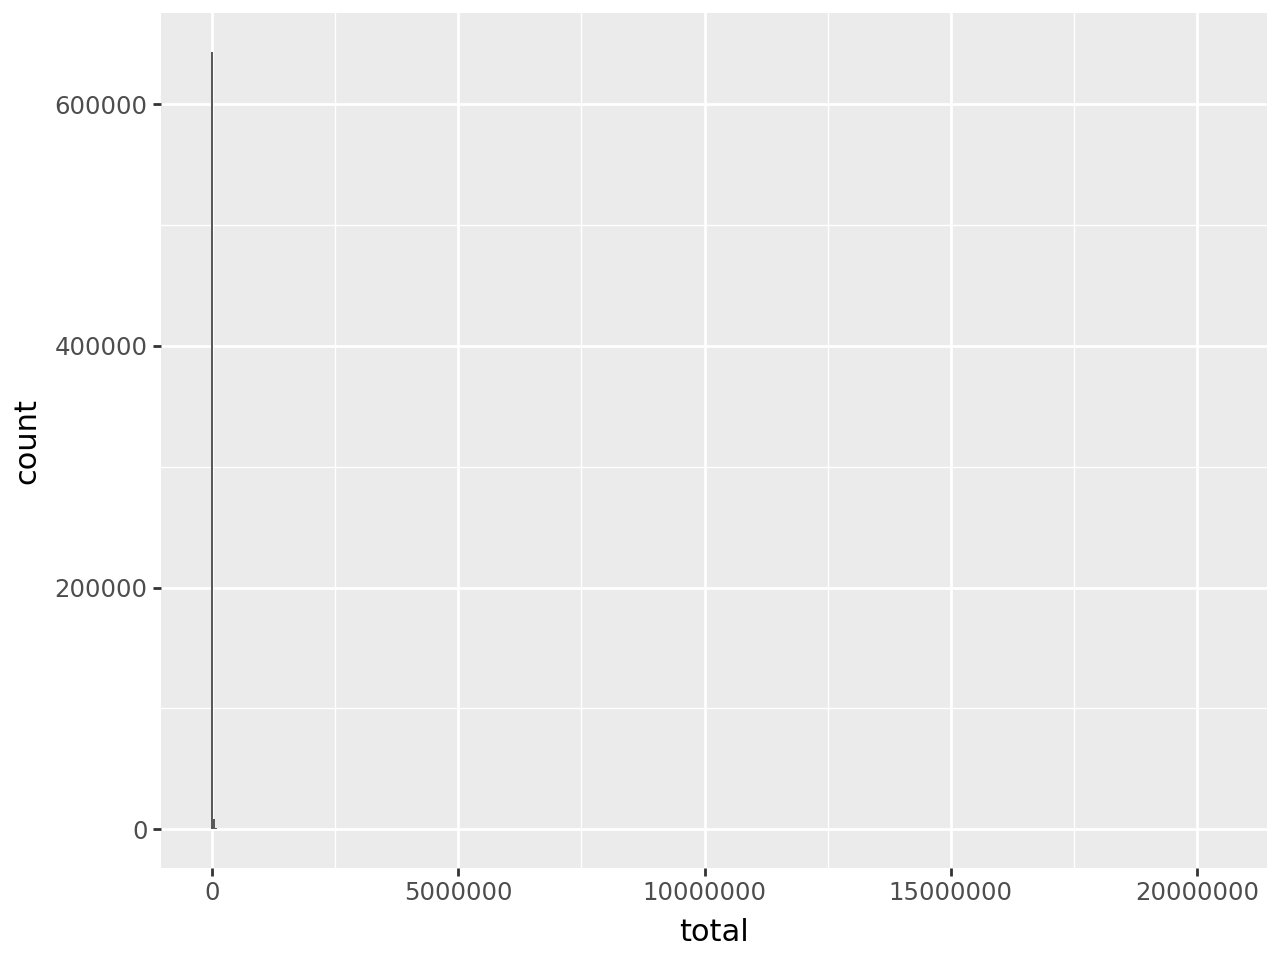

In [4]:
ggplot(cell_info[cell_info["cell_id"] != "None"], aes(x="total", color = "is__cell_barcode")) + geom_histogram(
    bins = 500)

In [5]:
cell_info["cell_id"].unique()

array([nan, '_cell_0', '_cell_1', ..., '_cell_14867', '_cell_14868',
       '_cell_14869'], dtype=object)

In [6]:
import anndata as ad
import scanpy as sc

In [7]:
def generate_my_counts_adata(samp, ending = ".npy", dir_=""):
    starting = True
    for wa in range(3):
        np_counts =  np.load("%speaks.%s%s"%(dir_, samp, ending))
        print(np.sum(np_counts != 0))
        df = pd.DataFrame(np_counts) 
        cells = list(pd.read_csv("%sconfirm_cell_names.%s_fragments.tsv.gz.csv"%(dir_, samp)).sort_values(
            by=["index"])["cell"])
        peaks = list(pd.read_csv("%sconfirm_peak_names.%s_fragments.tsv.gz.csv"%(dir_, samp)).sort_values(
            by=["index"])["peak"])
        return ad.AnnData(X=df, obs = pd.DataFrame(index = cells), var = pd.DataFrame(index = peaks))


In [9]:
naive = generate_my_counts_adata("Spleen_GSM5975167_scA_101", ending = "_fragments.tsv.gz.npy",
                                 dir_ = "../../../wherry_dataset/fragment_files/")

156571880


In [10]:
naive

AnnData object with n_obs × n_vars = 14870 × 223492

In [11]:
arm_d8 = generate_my_counts_adata("Spleen_GSM5975168_scA_102", ending = "_fragments.tsv.gz.npy",
                                 dir_ = "../../../wherry_dataset/fragment_files/")
arm_d8

126106840


AnnData object with n_obs × n_vars = 10488 × 223492

In [12]:
cl13_d8 = generate_my_counts_adata("Spleen_GSM5975171_scA_105", ending = "_fragments.tsv.gz.npy",
                                 dir_ = "../../../wherry_dataset/fragment_files/")
cl13_d8

99801259


AnnData object with n_obs × n_vars = 11625 × 223492

## combine with their annotations, TODO

In [13]:
sc.pp.calculate_qc_metrics(arm_d8, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(cl13_d8, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(naive, percent_top=None, log1p=False, inplace=True)

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


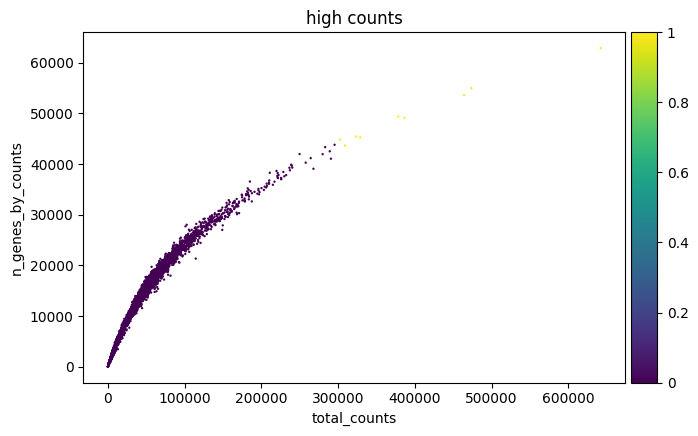

(10488, 223492)
(10479, 223492)
(10479, 128856)


/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


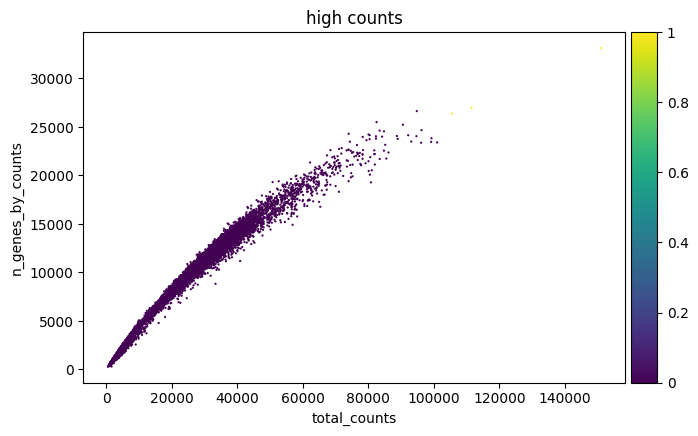

(11625, 223492)
(11622, 223492)
(11622, 110860)


/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


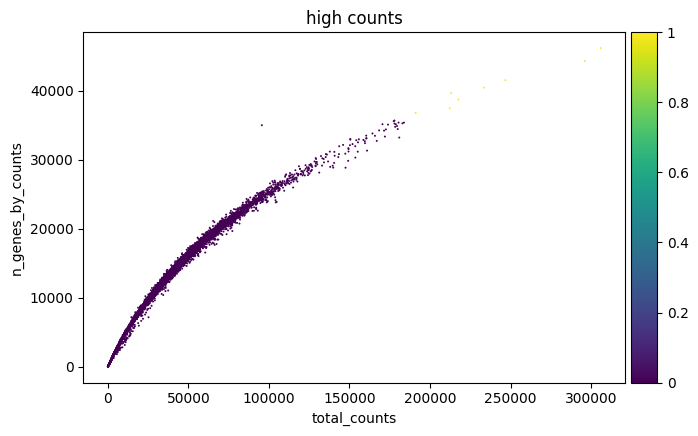

(14870, 223492)
(14862, 223492)
(14862, 113849)


In [15]:
final_genes = set()
for adat,thresh in zip([arm_d8, cl13_d8, naive], [300000, 105000, 185000]):
    adat.obs["high_counts"] = adat.obs["total_counts"] >= thresh
    sc.pl.scatter(adat, x="total_counts", y="n_genes_by_counts", color="high_counts")
    print(adat.shape)
    adat = adat[~adat.obs["high_counts"]].copy()
    print(adat.shape)
    sc.pp.filter_genes(adat, min_cells=0.005*adat.shape[0])
    print(adat.shape)    
    final_genes = final_genes.union(set(adat.var_names))

In [16]:
arm_d8.shape # 10479, 128856

(10488, 223492)

In [17]:
def update_adat(adat, n, thresh):
    adat = adat[adat.obs.total_counts <= thresh, list(final_genes)]
    adat.layers["raw_counts"] = adat.X.copy()
    adat.obs["sample"] = n
    adat.layers["fragment_counts"] = np.ceil(adat.layers["raw_counts"].copy()/2.0)
    adat.X = adat.layers["raw_counts"].copy()
    return adat

In [18]:
arm_d8 = update_adat(arm_d8, "arm_d8", 300000)
cl13_d8 = update_adat(cl13_d8, "cl13_d8", 105000)
naive = update_adat(naive, "naive", 185000)

/tmp/ipykernel_1835588/538284452.py:3: ImplicitModificationWarning: Setting element `.layers['raw_counts']` of view, initializing view as actual.
/tmp/ipykernel_1835588/538284452.py:3: ImplicitModificationWarning: Setting element `.layers['raw_counts']` of view, initializing view as actual.
/tmp/ipykernel_1835588/538284452.py:3: ImplicitModificationWarning: Setting element `.layers['raw_counts']` of view, initializing view as actual.


In [19]:
arm_d8.shape

(10479, 144841)

In [20]:
cl13_d8.shape

(11622, 144841)

In [21]:
naive.shape

(14862, 144841)

In [22]:
naive.write_h5ad("../anndatas/tmp_wherry_naive.h5ad")
cl13_d8.write_h5ad("../anndatas/tmp_wherry_cl13_d8.h5ad")
arm_d8.write_h5ad("../anndatas/tmp_wherry_arm_d8.h5ad")

## now Pearson residual normalization

In [3]:
def determine_theta(ad, n, thetas = [0.1, 1, 10, 10]):
    gene_means = pd.DataFrame()
    for theta in thetas: ## try different values for theta
        ad.X = ad.layers["fragment_counts"].copy()
        sc.experimental.pp.normalize_pearson_residuals(ad, theta = theta, inplace = True)
        lay = "theta_"+ str(round(theta, 1))
        ad.layers[lay] = ad.X.copy()
        gene_means = pd.concat([gene_means, pd.DataFrame({
            "gene_means": np.nanmean(ad.layers[lay], axis = 0), "gene_vars": np.nanvar(ad.layers[lay], axis = 0), 
            "theta": theta})])
    gene_means = gene_means.melt(ignore_index=False, value_vars = ["gene_means", "gene_vars"], id_vars = "theta", 
                    var_name = "stat", value_name = "value")
    print(gene_means.head())
    print(ggplot(gene_means[gene_means.value <= 10], aes(x="value", fill="stat")) + 
          geom_histogram(bins = 150) + theme(dpi=200) + labs(title = n) + \
          facet_grid("theta ~ stat", scales = "free_x") + geom_vline(pd.DataFrame(
        {"stat": ["gene_means", "gene_vars"], "x": [0, 1]}), aes(xintercept="x"), color="black"))    

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/experimental/pp/_normalization.py:58: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_1863727/2945602124.py:9: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_1863727/2945602124.py:9: RuntimeWarning: Degrees of freedom <= 0 for slice.


   theta        stat     value
0    0.1  gene_means -0.002370
1    0.1  gene_means -0.000115
2    0.1  gene_means -0.004652
3    0.1  gene_means -0.003558
4    0.1  gene_means -0.002549


/tmp/ipykernel_1863727/2945602124.py:14: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


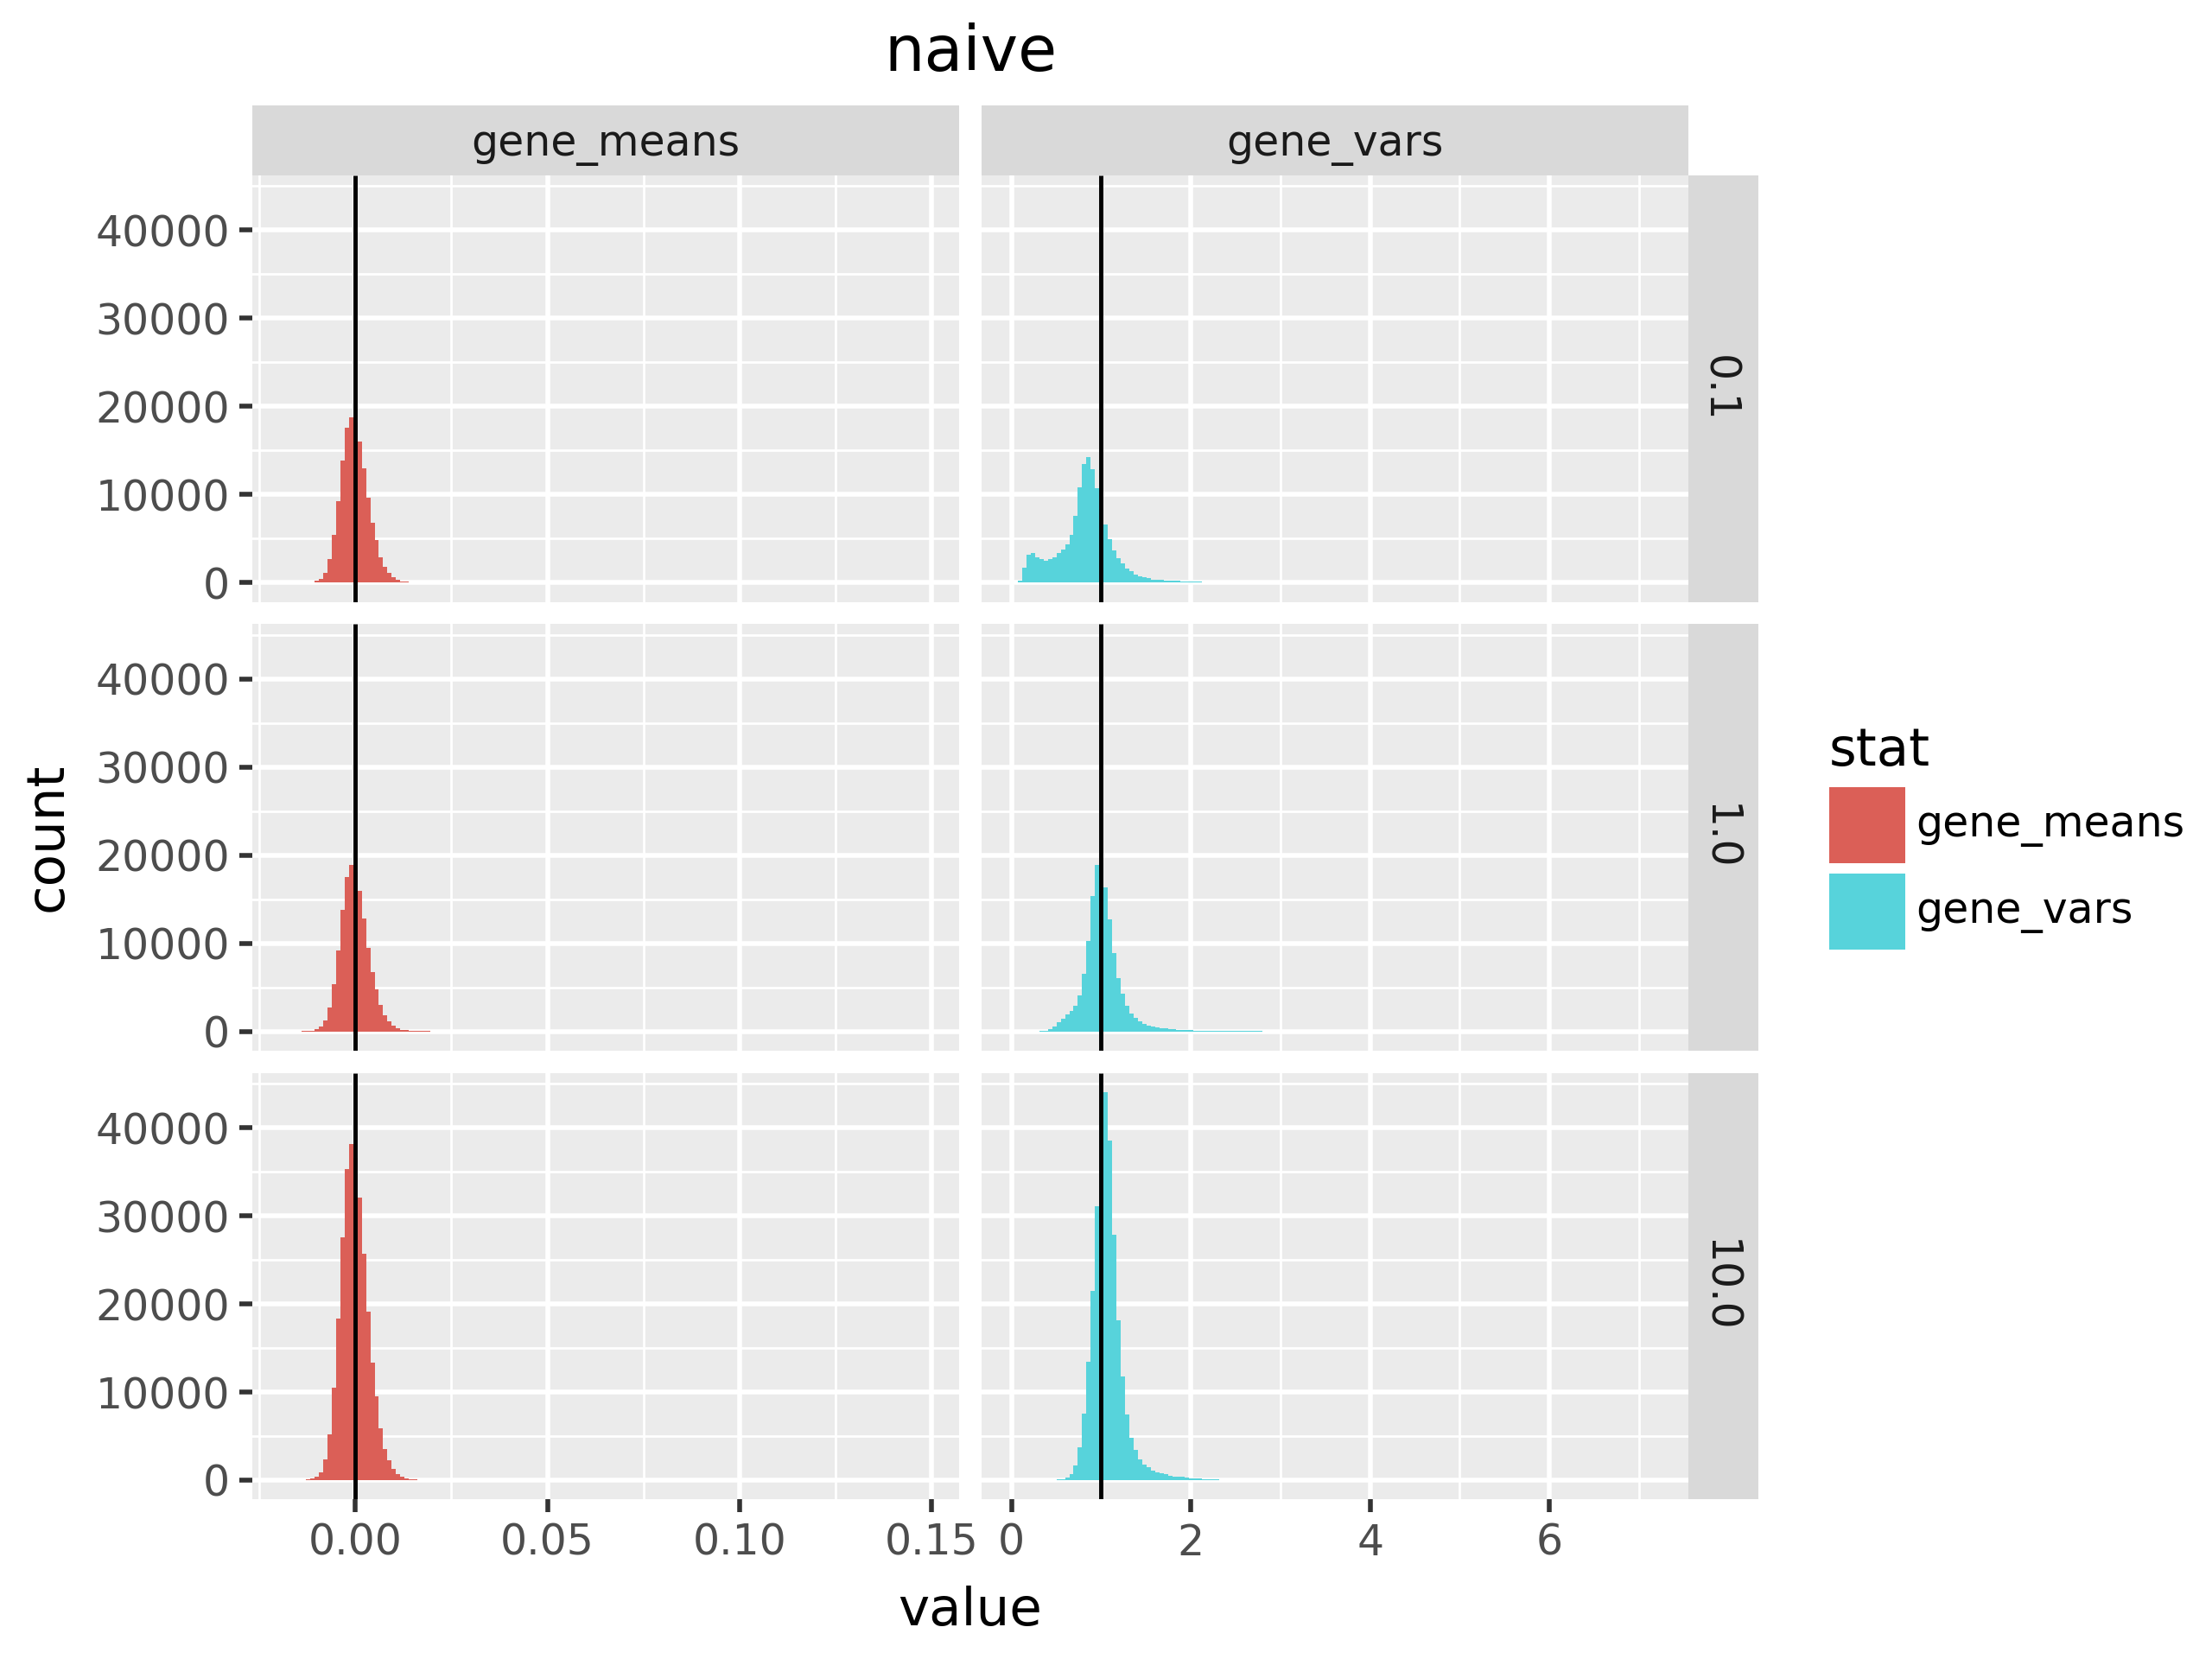

In [6]:
naive = sc.read_h5ad("../anndatas/tmp_wherry_naive.h5ad")
determine_theta(naive, "naive")

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/experimental/pp/_normalization.py:58: RuntimeWarning: invalid value encountered in divide
/tmp/ipykernel_1863727/2945602124.py:9: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_1863727/2945602124.py:9: RuntimeWarning: Degrees of freedom <= 0 for slice.


   theta        stat     value
0    0.1  gene_means  0.011461
1    0.1  gene_means -0.003319
2    0.1  gene_means -0.008958
3    0.1  gene_means -0.001679
4    0.1  gene_means -0.006286


/tmp/ipykernel_1863727/2945602124.py:14: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


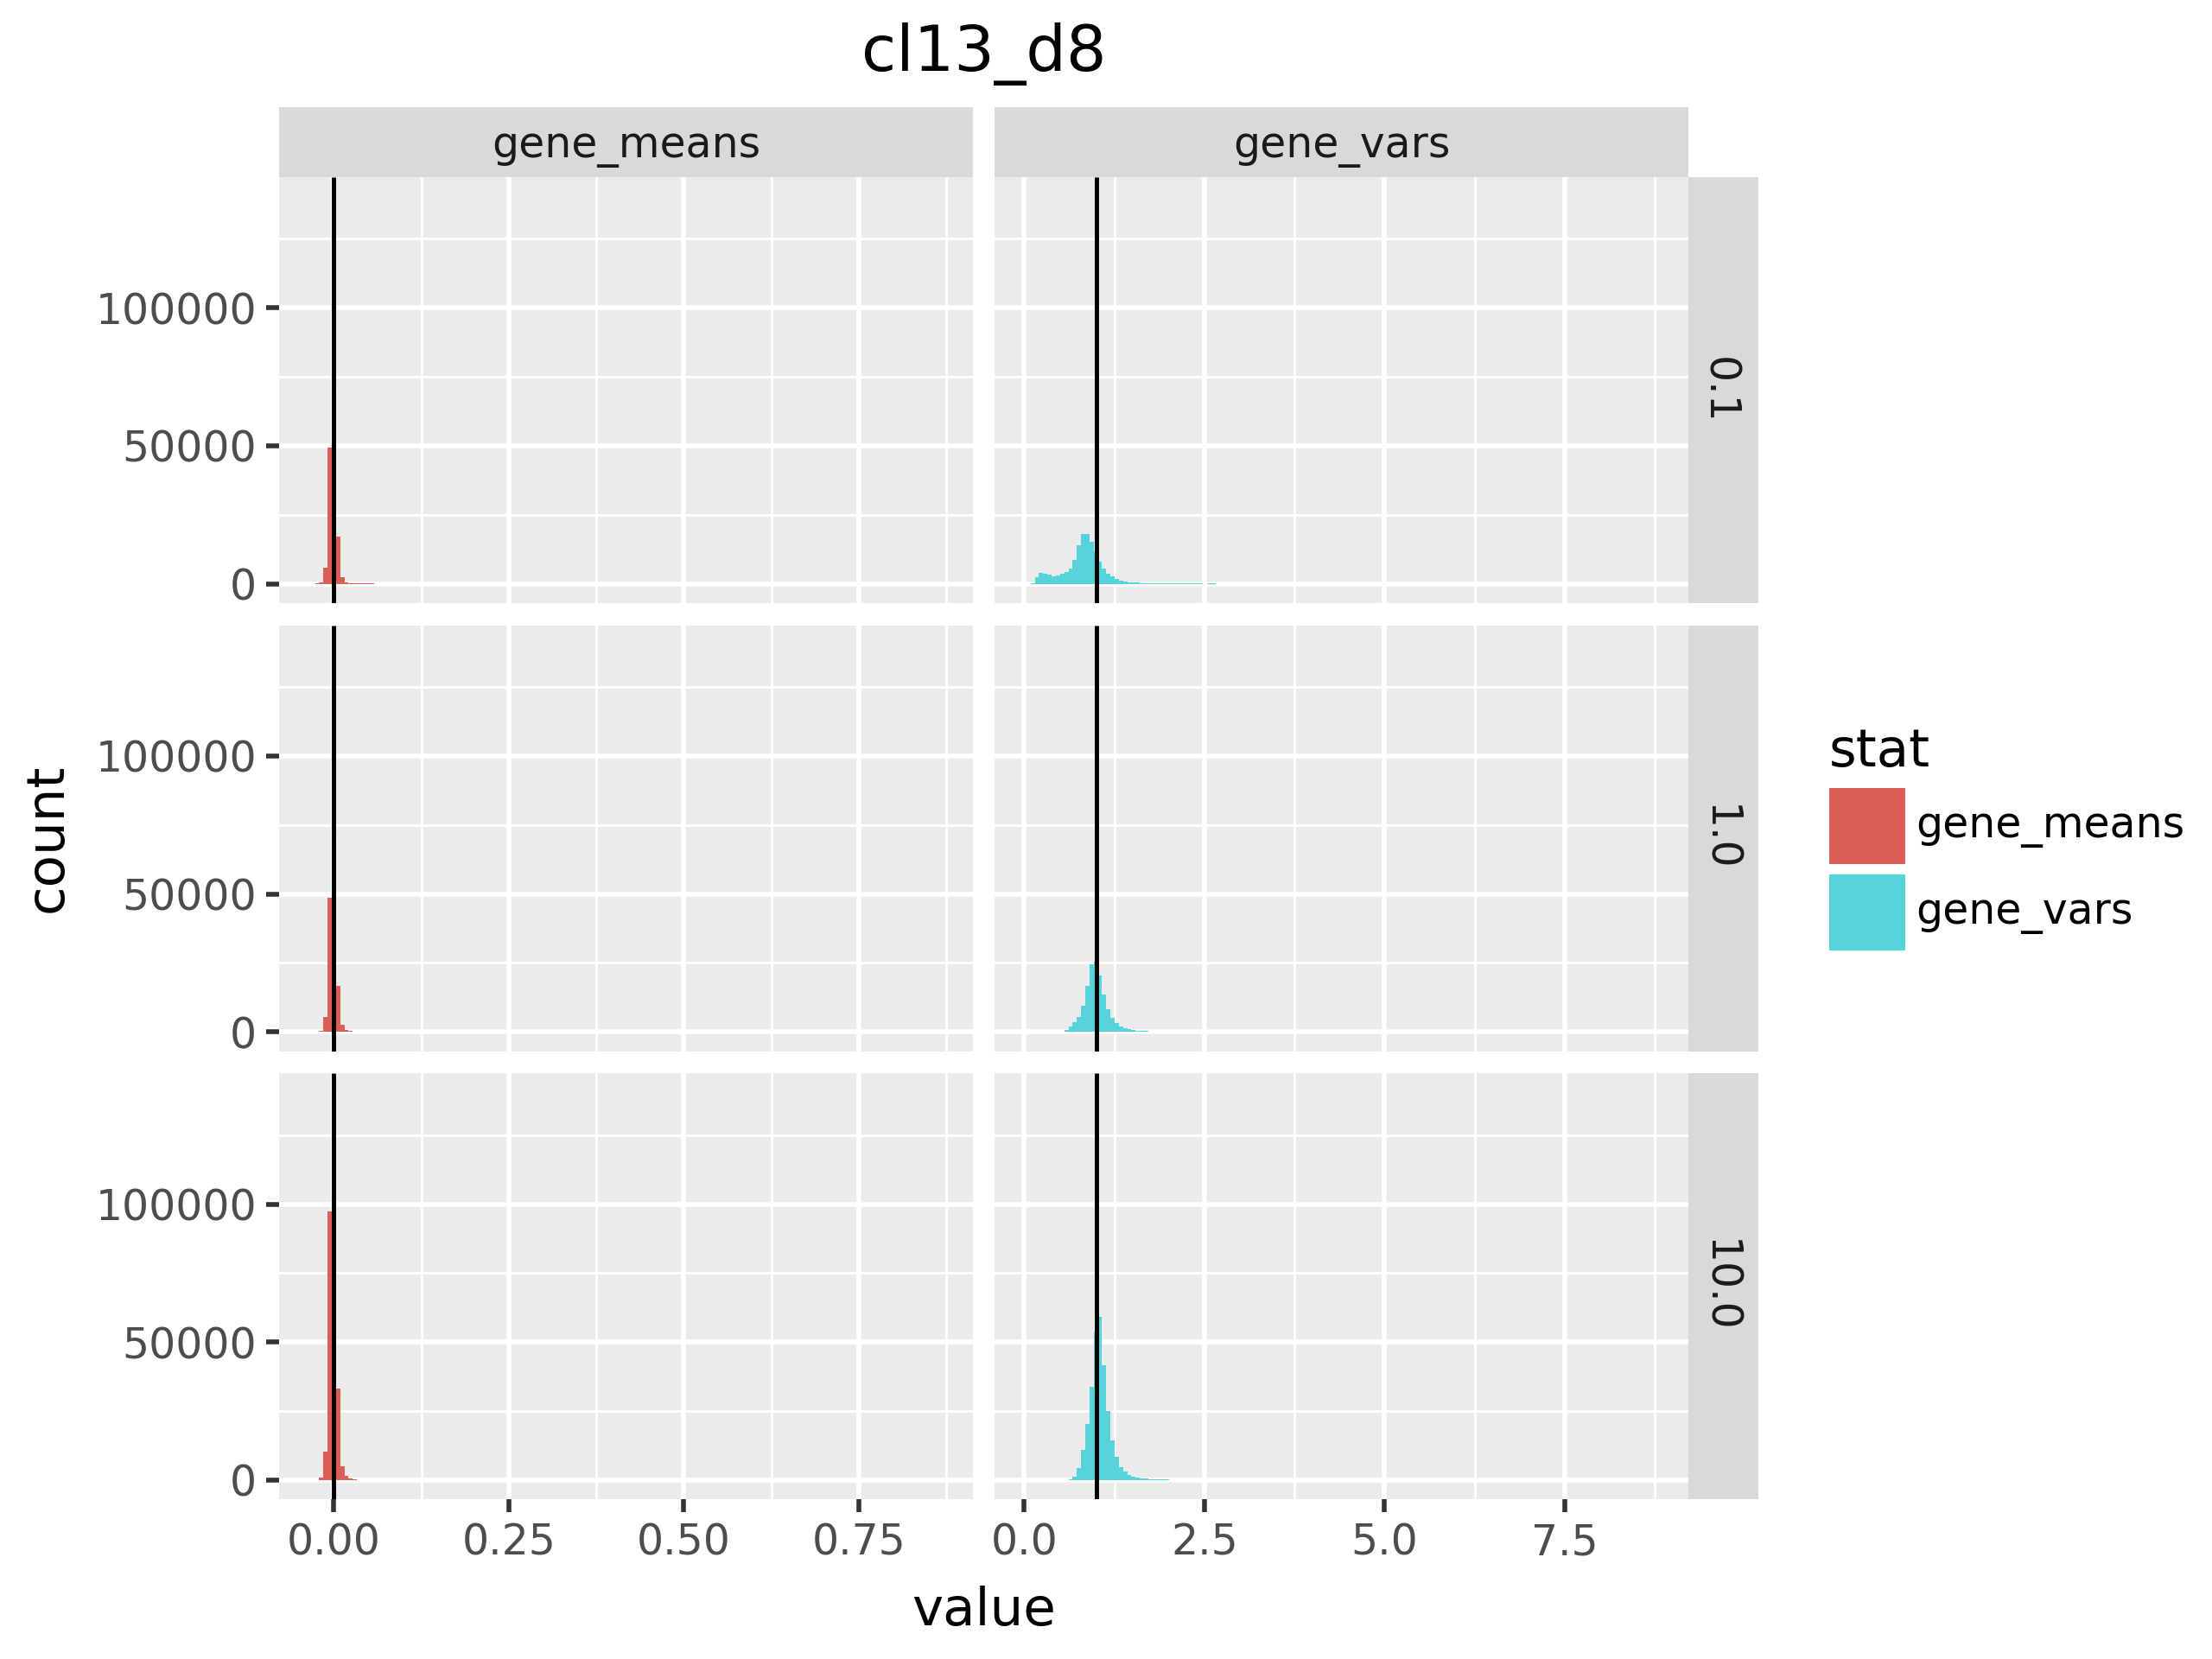

In [7]:
cl13_d8 = sc.read_h5ad("../anndatas/tmp_wherry_cl13_d8.h5ad")
determine_theta(cl13_d8, "cl13_d8")

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/experimental/pp/_normalization.py:58: RuntimeWarning: invalid value encountered in divide


   theta        stat     value
0    0.1  gene_means -0.001519
1    0.1  gene_means  0.001539
2    0.1  gene_means  0.000562
3    0.1  gene_means -0.000643
4    0.1  gene_means  0.001161


/tmp/ipykernel_1884626/2945602124.py:14: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


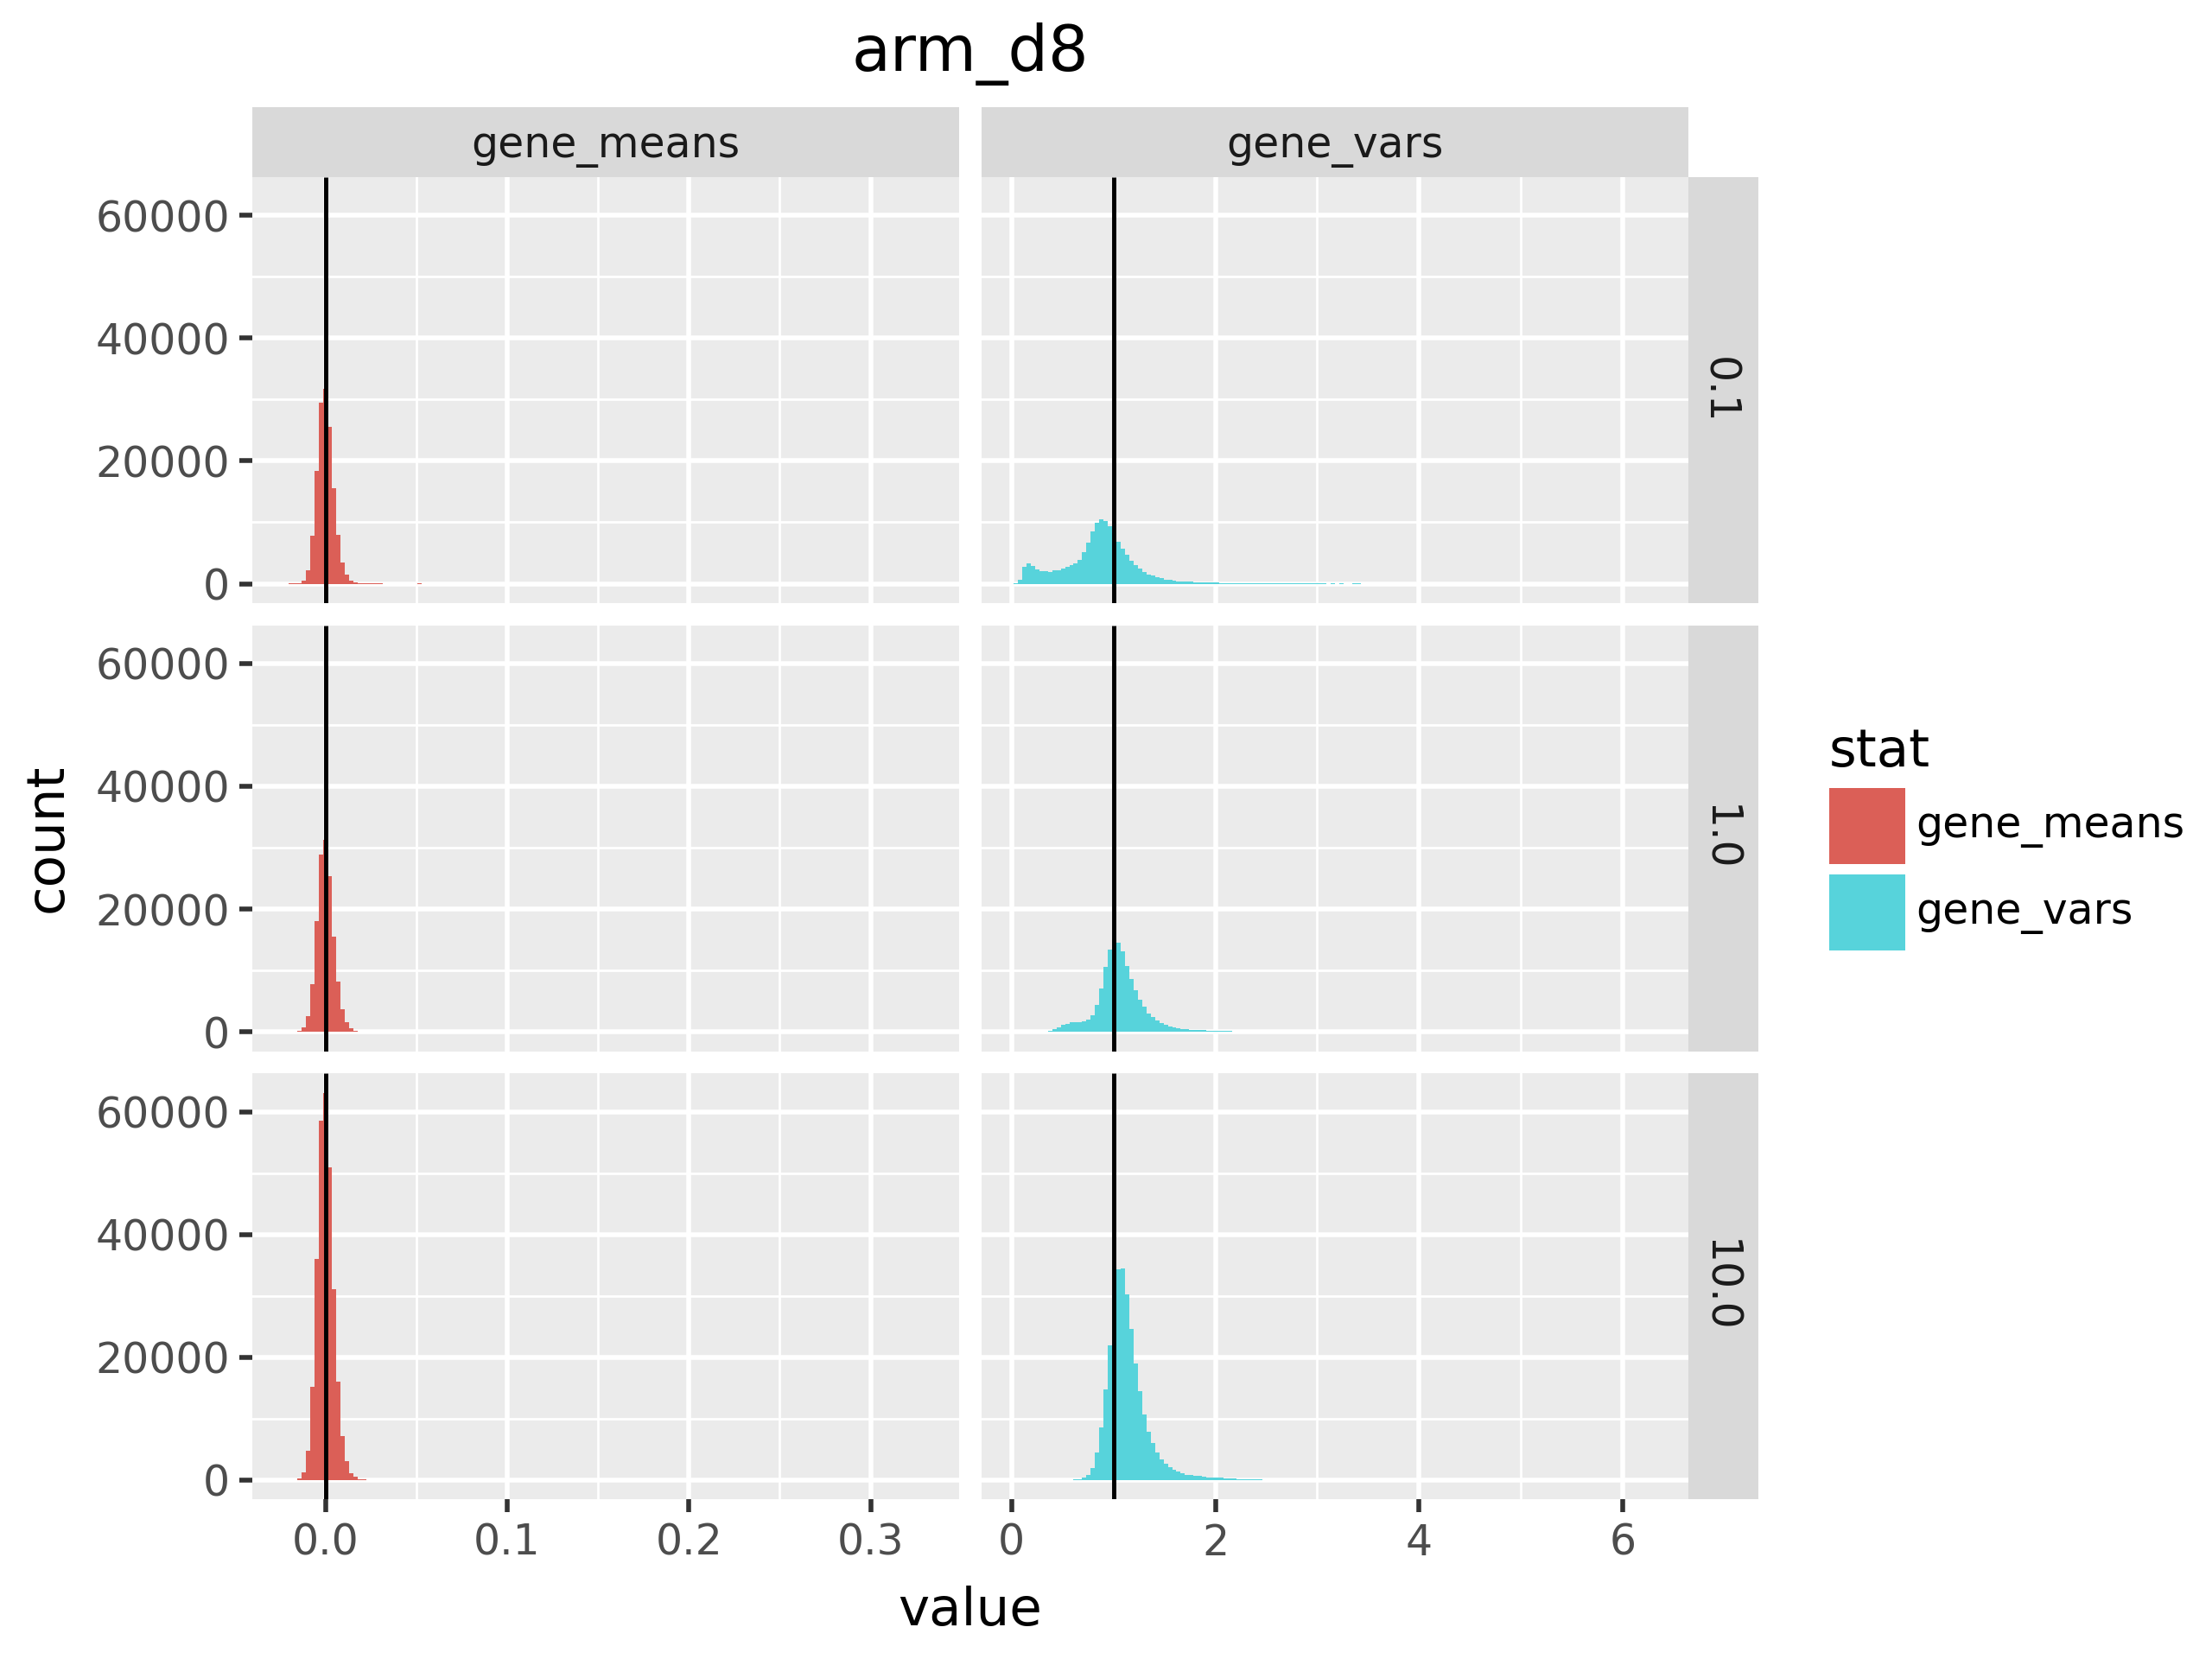

In [4]:
arm_d8 = sc.read_h5ad("../anndatas/tmp_wherry_arm_d8.h5ad")
determine_theta(arm_d8, "arm_d8")

In [5]:
# arm_d8 = sc.read_h5ad("../anndatas/tmp_wherry_arm_d8.h5ad")
cl13_d8 = sc.read_h5ad("../anndatas/tmp_wherry_cl13_d8.h5ad")
naive = sc.read_h5ad("../anndatas/tmp_wherry_naive.h5ad")

In [6]:
for adat in [arm_d8, cl13_d8, naive]:
    adat.X = adat.layers["fragment_counts"].copy()
    sc.experimental.pp.normalize_pearson_residuals(adat, theta = 1, inplace = True)
    adat.layers["pearson_norm"] = adat.X.copy()

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/experimental/pp/_normalization.py:58: RuntimeWarning: invalid value encountered in divide


In [7]:
def filter_ad_nans(ad, fragment_lay = "fragment_counts", norm_lay = "pearson_norm"):
    print("original ad shape: ")
    print(ad.shape)
    good_peaks = np.where(np.sum(ad.layers[fragment_lay], axis = 0) > 0)[0]
    good_cells = np.where(np.sum(np.isnan(ad[:, good_peaks].layers[norm_lay]), axis = 1) == 0)[0]
    filtered_ad = ad[good_cells,good_peaks]
    print("filtered ad shape: ")
    print(filtered_ad.shape)
    
    print("check no NAs now:")
    print(np.sum(np.isnan(filtered_ad.layers[norm_lay])))
    return filtered_ad

In [8]:
arm_d8 = filter_ad_nans(arm_d8)

original ad shape: 
(10479, 144841)
filtered ad shape: 
(10478, 144841)
check no NAs now:
0


In [9]:
cl13_d8 = filter_ad_nans(cl13_d8)

original ad shape: 
(11622, 144841)
filtered ad shape: 
(11622, 144839)
check no NAs now:
0


In [10]:
naive = filter_ad_nans(naive)

original ad shape: 
(14862, 144841)
filtered ad shape: 
(14859, 144835)
check no NAs now:
0


In [11]:
naive.write_h5ad("../anndatas/tmp_wherry_naive.h5ad")
cl13_d8.write_h5ad("../anndatas/tmp_wherry_cl13_d8.h5ad")
arm_d8.write_h5ad("../anndatas/tmp_wherry_arm_d8.h5ad")

In [2]:
print("here")

here


In [2]:
import scanpy as sc

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
naive = sc.read_h5ad("../anndatas/tmp_wherry_naive.h5ad")
cl13_d8 = sc.read_h5ad("../anndatas/tmp_wherry_cl13_d8.h5ad")
arm_d8 = sc.read_h5ad("../anndatas/tmp_wherry_arm_d8.h5ad")

In [ ]:
import anndata as ad

combined_wherry = ad.concat([arm_d8, cl13_d8, naive], merge="same", uns_merge="same")
combined_wherry.layers

In [ ]:
combined_wherry.shape

In [ ]:
del arm_d8, cl13_d8, naive

In [ ]:
combined_wherry.write_h5ad("../anndatas/wherry_combined_dataset.h5ad")

In [8]:
combined_wherry

AnnData object with n_obs × n_vars = 36959 × 144833
    obs: 'n_genes_by_counts', 'total_counts', 'high_counts', 'sample'
    uns: 'pearson_residuals_normalization'
    layers: 'fragment_counts', 'pearson_norm', 'raw_counts'

In [9]:
combined_wherry.layers

Layers with keys: fragment_counts, pearson_norm, raw_counts

In [10]:
combined_wherry.layers["pearson_norm"].shape

(36959, 144833)

In [13]:
np.sum(np.isnan(combined_wherry.layers["pearson_norm"])) ## hopefully is 0

0

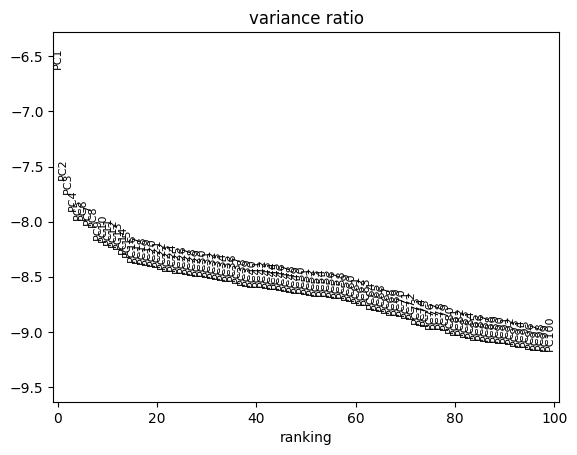

In [14]:
sc.tl.pca(combined_wherry, n_comps=100, svd_solver='arpack')
sc.pl.pca_variance_ratio(combined_wherry, log=True, n_pcs = 100)

In [15]:
sc.pp.neighbors(combined_wherry, n_neighbors=30, n_pcs=40, use_rep='X_pca', metric="cosine")

In [16]:
sc.tl.leiden(combined_wherry, resolution = 0.4)
combined_wherry.uns["leiden_colors"] = ["#7BD389", "#234057", "#D1234C", "#abbadf", "#EACCB6", "#FFEA76"]
sc.tl.umap(combined_wherry)

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_t

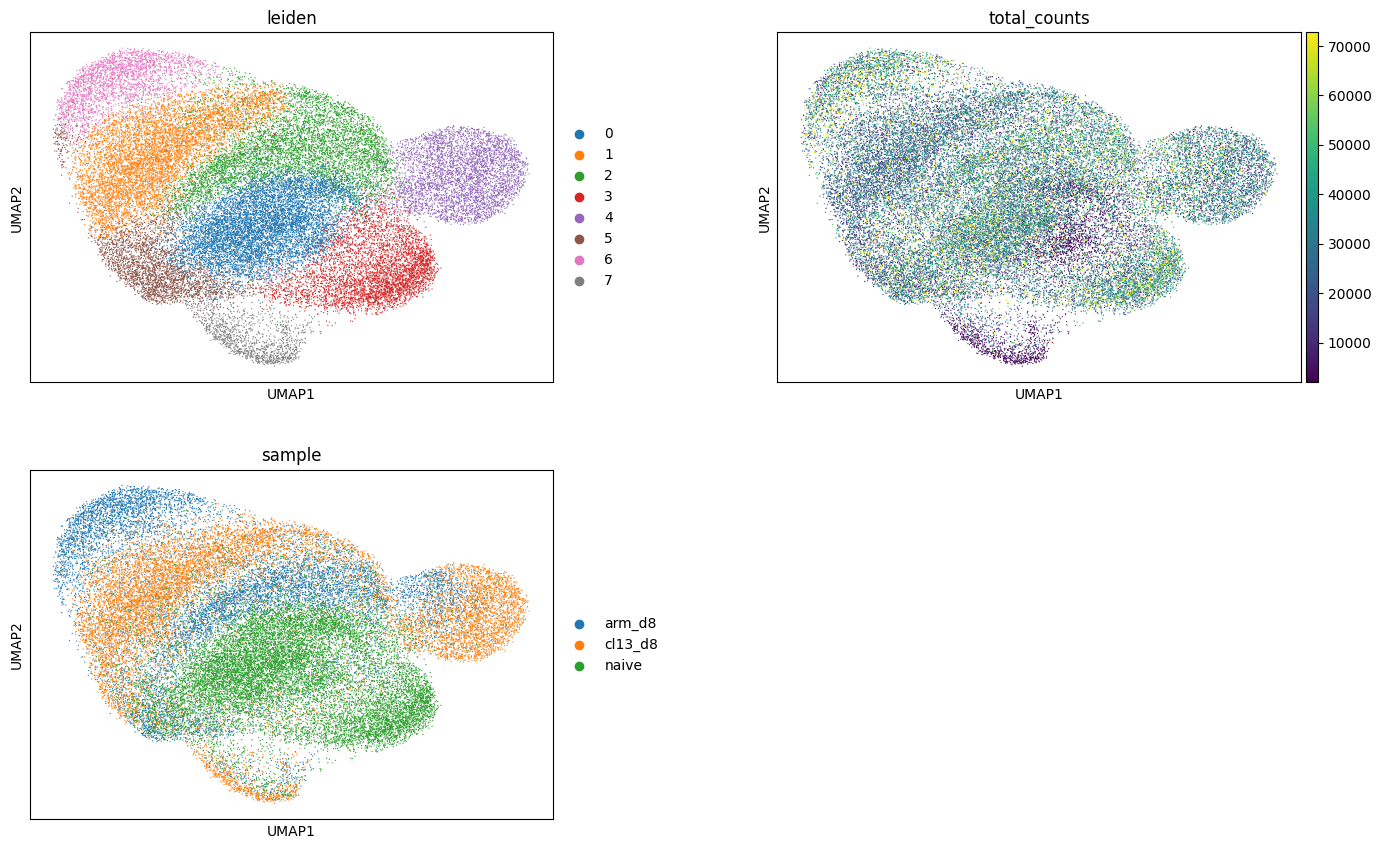

In [17]:
sc.pl.umap(combined_wherry, color=['leiden', 'total_counts', "sample"], 
           ncols= 2,  vmin='p5', vmax='p95', wspace = 0.3)

In [18]:
combined_wherry.write_h5ad("../anndatas/wherry_combined_dataset2.h5ad")

## now read in cell info file

In [19]:
cell_metadata = pd.read_csv("/Genomics/pritykinlab/sarah/multiomic_analysis/wherry_dataset/" + 
                            "fragment_files/cell_info.txt", index_col=0) # from their paper
cell_metadata.head()

,cellBarcode,sampleID,ClusterNames,ClusterIDs,nCount_peaks,nFeature_peaks,nCount_geneActivity,nFeature_geneActivity
AGTGTACGTCGTCGCA-1_1,AGTGTACGTCGTCGCA-1_1,Naive,Naive,0.0,24317,17732,23898,9181
TGCTTTATCTCATCCG-1_1,TGCTTTATCTCATCCG-1_1,Naive,Naive,0.0,23439,17336,24451,9272
GCGCATGTCCTAAGTG-1_1,GCGCATGTCCTAAGTG-1_1,Naive,Naive,0.0,23047,17595,23758,9524
TAATCGGGTCCAAGAG-1_1,TAATCGGGTCCAAGAG-1_1,Naive,Naive,0.0,24481,17893,24274,9311
AAGGTTCGTAAACGTA-1_1,AAGGTTCGTAAACGTA-1_1,Naive,Naive,0.0,24251,17750,24138,9208


In [20]:
cell_metadata["sampleID"] = cell_metadata["sampleID"].str.lower()

In [21]:
cell_metadata["cell"] = cell_metadata["cellBarcode"].str.split("_").str[0]

In [22]:
combined_wherry.shape

(36959, 144833)

In [23]:
combined_wherry.obs

,n_genes_by_counts,total_counts,high_counts,sample,leiden
AAACGAAAGACAGTGC-1,9799,26000,False,arm_d8,2
AAACGAAAGACGTCAG-1,14750,43753,False,arm_d8,2
AAACGAAAGACTAATG-1,11897,35527,False,arm_d8,2
AAACGAAAGAGTGGTC-1,1517,2904,False,arm_d8,4
AAACGAAAGATCACCT-1,14391,42333,False,arm_d8,6
...,...,...,...,...,...
TTTGTGTTCCTCCAGT-1,12401,34969,False,naive,3
TTTGTGTTCGCACAAT-1,10842,28608,False,naive,3
TTTGTGTTCGCATACA-1,19970,71089,False,naive,3
TTTGTGTTCGGTTCCT-1,18480,60905,False,naive,0


In [24]:
combined_wherry.obs["cell"] = combined_wherry.obs_names + "." + combined_wherry.obs["sample"].astype(str)

In [25]:
len(combined_wherry.obs["cell"] .unique())

36959

In [26]:
len(combined_wherry.obs_names.unique())

36268

In [29]:
cell_metadata.shape

(42735, 9)

In [32]:
cell_metadata.groupby("sampleID").count() ## they filtered a lot of cells

,cellBarcode,ClusterNames,ClusterIDs,nCount_peaks,nFeature_peaks,nCount_geneActivity,nFeature_geneActivity,cell
sampleID,,,,,,,,
arm_d15,5999,5999,5999,5999,5999,5999,5999,5999
arm_d30,6058,6058,6058,6058,6058,6058,6058,6058
arm_d8,4833,4832,4832,4833,4833,4833,4833,4833
cl13_d15,4859,4859,4859,4859,4859,4859,4859,4859
cl13_d30,6415,6415,6415,6415,6415,6415,6415,6415
cl13_d8,6957,6952,6952,6957,6957,6957,6957,6957
naive,7614,7614,7614,7614,7614,7614,7614,7614


In [33]:
combined_wherry.obs.groupby("sample").count()

/tmp/ipykernel_881568/1200767983.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,n_genes_by_counts,total_counts,high_counts,leiden,cell
sample,,,,,
arm_d8,10478,10478,10478,10478,10478
cl13_d8,11622,11622,11622,11622,11622
naive,14859,14859,14859,14859,14859


In [34]:
new_obs = combined_wherry.obs.reset_index().merge(cell_metadata, right_on = ["cell", "sampleID"], left_on = [
    "index", "sample"], how = "inner").rename(columns = {"cell_x": "cell"}).set_index("cell")
new_obs

,index,n_genes_by_counts,total_counts,high_counts,sample,leiden,cellBarcode,sampleID,ClusterNames,ClusterIDs,nCount_peaks,nFeature_peaks,nCount_geneActivity,nFeature_geneActivity,cell_y
cell,,,,,,,,,,,,,,,
AAACGAAAGACAGTGC-1.arm_d8,AAACGAAAGACAGTGC-1,9799,26000,False,arm_d8,2,AAACGAAAGACAGTGC-1_2,arm_d8,Eff,1.0,13401,11050,13610,6830,AAACGAAAGACAGTGC-1
AAACGAAAGACGTCAG-1.arm_d8,AAACGAAAGACGTCAG-1,14750,43753,False,arm_d8,2,AAACGAAAGACGTCAG-1_2,arm_d8,Eff,1.0,21951,16675,21230,8750,AAACGAAAGACGTCAG-1
AAACGAAAGACTAATG-1.arm_d8,AAACGAAAGACTAATG-1,11897,35527,False,arm_d8,2,AAACGAAAGACTAATG-1_2,arm_d8,Eff,1.0,18055,13561,17768,7728,AAACGAAAGACTAATG-1
AAACGAAAGATCACCT-1.arm_d8,AAACGAAAGATCACCT-1,14391,42333,False,arm_d8,6,AAACGAAAGATCACCT-1_2,arm_d8,CTL,2.0,21611,16472,22047,9065,AAACGAAAGATCACCT-1
AAACGAAAGCGTGTTT-1.arm_d8,AAACGAAAGCGTGTTT-1,12695,40388,False,arm_d8,2,AAACGAAAGCGTGTTT-1_2,arm_d8,Eff,1.0,20632,14775,21402,8438,AAACGAAAGCGTGTTT-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTGTGTCGTGC-1.naive,TTTGTGTGTGTCGTGC-1,12075,32193,False,naive,3,TTTGTGTGTGTCGTGC-1_1,naive,Naive,0.0,16378,13355,16457,7986,TTTGTGTGTGTCGTGC-1
TTTGTGTGTTCCAATG-1.naive,TTTGTGTGTTCCAATG-1,10897,29997,False,naive,0,TTTGTGTGTTCCAATG-1_1,naive,Naive,0.0,15175,12014,15015,7295,TTTGTGTGTTCCAATG-1
TTTGTGTTCCTCCAGT-1.naive,TTTGTGTTCCTCCAGT-1,12401,34969,False,naive,3,TTTGTGTTCCTCCAGT-1_1,naive,Naive,0.0,17741,13978,18283,8204,TTTGTGTTCCTCCAGT-1


In [39]:
combined_wherry.obs = combined_wherry.obs.set_index("cell")

In [40]:
combined_wherry = combined_wherry[new_obs.index,:]

In [41]:
combined_wherry

View of AnnData object with n_obs × n_vars = 19404 × 144833
    obs: 'n_genes_by_counts', 'total_counts', 'high_counts', 'sample', 'leiden'
    uns: 'pearson_residuals_normalization', 'pca', 'neighbors', 'leiden', 'leiden_colors', 'umap', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'fragment_counts', 'pearson_norm', 'raw_counts'
    obsp: 'distances', 'connectivities'

In [44]:
# combined_wherry.obs = new_obs.loc[combined_wherry.obs_names]
combined_wherry.obs

,index,n_genes_by_counts,total_counts,high_counts,sample,leiden,cellBarcode,sampleID,ClusterNames,ClusterIDs,nCount_peaks,nFeature_peaks,nCount_geneActivity,nFeature_geneActivity,cell_y
cell,,,,,,,,,,,,,,,
AAACGAAAGACAGTGC-1.arm_d8,AAACGAAAGACAGTGC-1,9799,26000,False,arm_d8,2,AAACGAAAGACAGTGC-1_2,arm_d8,Eff,1.0,13401,11050,13610,6830,AAACGAAAGACAGTGC-1
AAACGAAAGACGTCAG-1.arm_d8,AAACGAAAGACGTCAG-1,14750,43753,False,arm_d8,2,AAACGAAAGACGTCAG-1_2,arm_d8,Eff,1.0,21951,16675,21230,8750,AAACGAAAGACGTCAG-1
AAACGAAAGACTAATG-1.arm_d8,AAACGAAAGACTAATG-1,11897,35527,False,arm_d8,2,AAACGAAAGACTAATG-1_2,arm_d8,Eff,1.0,18055,13561,17768,7728,AAACGAAAGACTAATG-1
AAACGAAAGATCACCT-1.arm_d8,AAACGAAAGATCACCT-1,14391,42333,False,arm_d8,6,AAACGAAAGATCACCT-1_2,arm_d8,CTL,2.0,21611,16472,22047,9065,AAACGAAAGATCACCT-1
AAACGAAAGCGTGTTT-1.arm_d8,AAACGAAAGCGTGTTT-1,12695,40388,False,arm_d8,2,AAACGAAAGCGTGTTT-1_2,arm_d8,Eff,1.0,20632,14775,21402,8438,AAACGAAAGCGTGTTT-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTGTGTCGTGC-1.naive,TTTGTGTGTGTCGTGC-1,12075,32193,False,naive,3,TTTGTGTGTGTCGTGC-1_1,naive,Naive,0.0,16378,13355,16457,7986,TTTGTGTGTGTCGTGC-1
TTTGTGTGTTCCAATG-1.naive,TTTGTGTGTTCCAATG-1,10897,29997,False,naive,0,TTTGTGTGTTCCAATG-1_1,naive,Naive,0.0,15175,12014,15015,7295,TTTGTGTGTTCCAATG-1
TTTGTGTTCCTCCAGT-1.naive,TTTGTGTTCCTCCAGT-1,12401,34969,False,naive,3,TTTGTGTTCCTCCAGT-1_1,naive,Naive,0.0,17741,13978,18283,8204,TTTGTGTTCCTCCAGT-1


In [46]:
combined_wherry.write_h5ad("../anndatas/wherry_combined_dataset.h5ad") 

In [47]:
from glob import glob

def make_scores(fn, up_name, down_name, adat,  lfc_threshold = 1):
    df = pd.read_csv(fn)
    up_peaks = list(df[df["log2FoldChange"] > 1]["Unnamed: 0"])
    down_peaks = list(df[df["log2FoldChange"] < -1]["Unnamed: 0"])
    print("num up peaks: %s vs num down peaks: %s"%(len(up_peaks), len(down_peaks)))
    sc.tl.score_genes(adat, score_name=up_name, gene_list=up_peaks)
    sc.tl.score_genes(adat, score_name=down_name, gene_list=down_peaks)    
    
def score_all_bn(glob_fns, adat): 
    for fn in glob(glob_fns):
        print(fn)
        up = fn.split("/")[-1].split(".csv")[0].replace("exhausted_", "dys_").replace("_til", "")
        down = up.split("_")[0] + "_" + up.split("_vs_")[1] + "_vs_" + up.split("_vs_")[0].split("_", 1)[1]
        print("%s\t%s"%(up, down))
        make_scores(fn, up_name=up, down_name = down, lfc_threshold = 1, adat = adat)
    

## Remake KNN after filtering cells

In [48]:
sc.pp.neighbors(combined_wherry, n_neighbors=30, n_pcs=40, use_rep='X_pca', metric="cosine")

In [49]:
sc.tl.leiden(combined_wherry, resolution=0.4)
sc.tl.umap(combined_wherry)

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_t

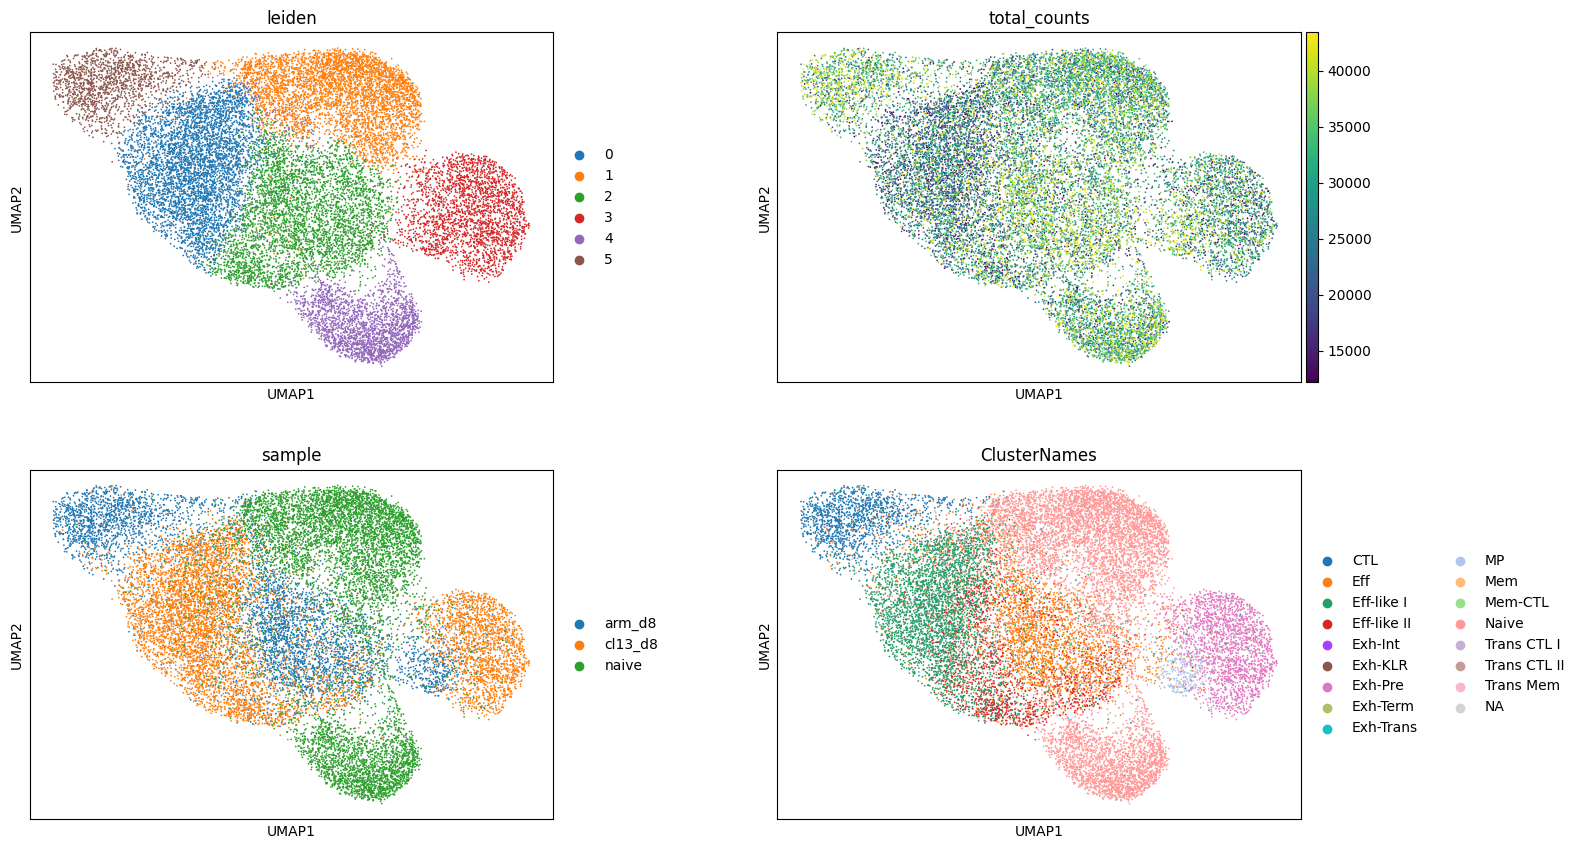

In [50]:
sc.pl.umap(combined_wherry, color=['leiden', 'total_counts', "sample", "ClusterNames"], 
           ncols= 2,  vmin='p5', vmax='p95', wspace = 0.3)

In [54]:
score_all_bn("/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/*prog*", 
             combined_wherry)

/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Miller_cd8_exhausted_til_d20_term_vs_cd8_exhausted_til_d20_prog.csv
Miller_cd8_dys_d20_term_vs_cd8_dys_d20_prog	Miller_cd8_dys_d20_prog_vs_cd8_dys_d20_term
num up peaks: 2815 vs num down peaks: 4766
/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Miller_cd8_exhausted_lcmv_d30_term_vs_cd8_exhausted_lcmv_d30_prog.csv
Miller_cd8_dys_lcmv_d30_term_vs_cd8_dys_lcmv_d30_prog	Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_lcmv_d30_term
num up peaks: 4529 vs num down peaks: 8639


/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Chen_cd8_naive_vs_cd8_exhausted_melanoma_progenitor.csv
Chen_cd8_naive_vs_cd8_dys_melanoma_progenitor	Chen_cd8_dys_melanoma_progenitor_vs_cd8_naive
num up peaks: 16159 vs num down peaks: 14916


/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Miller_cd8_exhausted_til_d20_term_vs_cd8_exhausted_lcmv_d30_prog.csv
Miller_cd8_dys_d20_term_vs_cd8_dys_lcmv_d30_prog	Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_d20_term
num up peaks: 15566 vs num down peaks: 17320


/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Miller_cd8_exhausted_til_d20_prog_vs_cd8_exhausted_lcmv_d30_term.csv
Miller_cd8_dys_d20_prog_vs_cd8_dys_lcmv_d30_term	Miller_cd8_dys_lcmv_d30_term_vs_cd8_dys_d20_prog
num up peaks: 8807 vs num down peaks: 5440
/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Chen_cd8_exhausted_melanoma_progenitor_vs_cd8_exhausted_melanoma.csv
Chen_cd8_dys_melanoma_progenitor_vs_cd8_dys_melanoma	Chen_cd8_dys_melanoma_vs_cd8_dys_melanoma_progenitor
num up peaks: 2641 vs num down peaks: 1850


/Genomics/pritykinlab/sarah/multiomic_analysis/updated_bulk_peak_set/bulk_signatures/Miller_cd8_exhausted_til_d20_prog_vs_cd8_exhausted_lcmv_d30_prog.csv
Miller_cd8_dys_d20_prog_vs_cd8_dys_lcmv_d30_prog	Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_d20_prog
num up peaks: 7221 vs num down peaks: 8623


In [55]:
combined_wherry.obs["progenitor score"] = np.nan
combined_wherry.obs.loc[combined_wherry.obs["ClusterNames"].isin(["MP", "Exh-Pre"]), "progenitor score"] = \
combined_wherry[combined_wherry.obs["ClusterNames"].isin(["MP", "Exh-Pre"])].obs["Miller_cd8_dys_d20_prog_vs_cd8_dys_d20_term"]

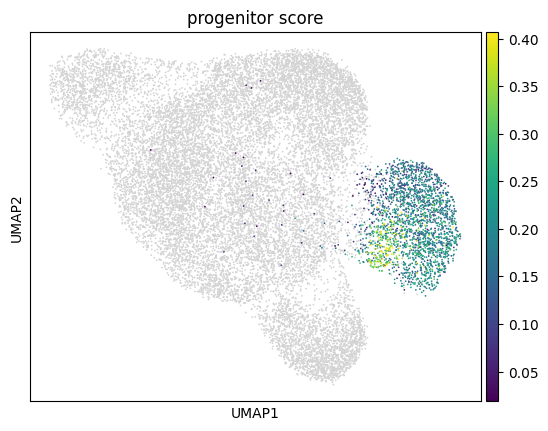

In [58]:
sc.pl.umap(combined_wherry, color = "progenitor score", vmin = "p1", vmax = "p99")

In [57]:
combined_wherry.write_h5ad("../anndatas/wherry_combined_dataset2.h5ad") 